# Demand Simulator

## Objetivos
Crear una clase de python que permita simular la demanda del planificador de demanda horaria.

La misma debera inicializarse con:
entry_hours:es un array de enteros entre 0 y 23 
close_hour: es un entero entre 0 y 23 o None si no hay ningun horario de cierre, 
fixed_holidays: es un entero indicando el numero de la semana, entre 0 y 6 o None si no hay ninguno fijo 
var_holidays: es un entero 0,1 o 2. Debe validarse que no haya mas de 2 dias de franco entre el fixed_holidays y el var_holidays

## Metodos:

### Compute_coverage: 

Objetivo: generar la matriz de cobertura con los recursos totales (hasta aca sin ruido incorporado)
Inputs: mod_4, mod_6, mod_8 que equivalen a la cantidad de recursos de 4, 6 y 8 hs disponibles

En funcion de eso y para cada uno, por semana debe elegir semana (debera completar las 4), dias franco y horarios de ingreso por semana.
Puede incluir funciones ocultas para calcular una lista de recursos, una lista de horarios de ingreso y una lista de francos. Por ejemplo, para calcular de forma aleatoria la secuencia de modalidades de recurso podria usar:

resources_list = [4 for i in range(mod_4)] + [6 for i in range(mod_6)] + [8 for i in range(mod_8)]
random.shuffle(resources_list)
amount_of_resources = len(resources_list)
resources_list_week = [item for item in resources_list for _ in range(4)]
resources_list_week


Se podria hacer algo parecido para los dias francos considerando que admite hasta 2 dias francos y que los horarios deben cumplir con la condicion de legalidad, esto es, un recuros de 8hs por ejemplo, no podria entrar a las 18 si la empresa cierra a las 22.

Output: 
R: Matriz de recursos acumulada (o la demanda cubierta)
T: Trayectoria de acciones, un objeto de acciones con las Rt y la accion tomada. Ejemplo: [{"action_id":, "Rt":[numpy.array]}] 

Con el siguiente dominio de acciones:

0: eleccion de modalidad 4
1: eleccion de modalidad 6
2: eleccion de modalidad 8
3: eleccion de hora de ingreso 0
..
25: eleccon de hora de ingreso 23
26: eleccion de franco 0 (domingo) - un solo franco
.. etc (ver tabla de combinacion de francos)



resources_list = [4 for i in range(mod_4)] + [6 for i in range(mod_6)] + [8 for i in range(mod_8)]
random.shuffle(resources_list)
amount_of_resources = len(resources_list)

y para reptir esa accion por semana:
resources_list_week = [item for item in resources_list for _ in range(4)]

Ahora si hacemos algo parecido con los horarios de ingreso y los francos. No es posible combinar las listas resultantes en tuplas y generar todas las trayectorias, etc.
Decime que entendiste y que te parece 




## Librerias Necesarias

In [11]:
# Librerias
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from typing import Any


# Módulos
from schemas import ProblemSetup, WorkforceState
from demand_simulator import DemandSimulator
from demand_noise import DemandNoiseGenerator

## Funciones utiles

#### Heatmap matrices

In [9]:
def _annotate_heatmap(ax, matrix, fontsize=5, min_value_to_show=1):
    """
    Escribe valores dentro del heatmap solo cuando superan cierto umbral.
    Esto evita saturar visualmente la matriz.
    """
    for h in range(matrix.shape[0]):
        for d in range(matrix.shape[1]):
            value = int(matrix[h, d])
            if value >= min_value_to_show:
                ax.text(
                    d,
                    h,
                    str(value),
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                )


def _format_matrix_axis(ax, title):
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Día")
    ax.set_ylabel("Hora")

    ax.set_xticks(np.arange(0, 28, 1))
    ax.set_yticks(np.arange(0, 24, 2))

    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

    ax.set_xlim(-0.5, 27.5)
    ax.set_ylim(23.5, -0.5)

    for x in np.arange(6.5, 28, 7):
        ax.axvline(x=x, linewidth=1.2, alpha=0.35)


def _add_week_labels(ax):
    """
    Agrega etiquetas visuales para las 4 semanas.
    """
    week_centers = [3, 10, 17, 24]

    for i, center in enumerate(week_centers):
        ax.text(
            center,
            -1.6,
            f"S{i + 1}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            clip_on=False,
        )


def plot_noise_components(noise_result, figsize=(16, 5)):
    """
    Grafica los componentes diarios y horarios de propensión de demanda.

    Se separa de los heatmaps para que las curvas sean legibles.
    """
    days = np.arange(28)
    hours = np.arange(24)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )

    ax_day, ax_hour = axes

    # ------------------------------------------------------------
    # Componente diaria
    # ------------------------------------------------------------
    ax_day.plot(
        days,
        noise_result.daily_component,
        linewidth=2.6,
        label="Componente diaria combinada",
    )

    for i, contribution in enumerate(noise_result.daily_peak_contributions):
        peak = noise_result.daily_peaks[i]

        ax_day.plot(
            days,
            contribution,
            linestyle="--",
            linewidth=1.3,
            alpha=0.75,
            label=(
                f"Pico {peak['peak_id']} "
                f"μ={peak['mu']:.1f}, "
                f"σ={peak['sigma']:.1f}, "
                f"λ={peak['intensity_lambda']:.2f}"
            ),
        )

    ax_day.set_title("Propensión diaria", fontsize=13, pad=10)
    ax_day.set_xlabel("Día del horizonte")
    ax_day.set_ylabel("Q día")
    ax_day.set_xlim(0, 27)
    ax_day.set_xticks(np.arange(0, 28, 2))
    ax_day.grid(True, alpha=0.25)

    if len(noise_result.daily_peaks) > 0:
        ax_day.legend(fontsize=8, frameon=False)
    else:
        ax_day.legend(["Componente diaria plana"], fontsize=8, frameon=False)

    # ------------------------------------------------------------
    # Componente horaria
    # ------------------------------------------------------------
    ax_hour.plot(
        hours,
        noise_result.hourly_component,
        linewidth=2.6,
        label="Componente horaria combinada",
    )

    for i, contribution in enumerate(noise_result.hourly_peak_contributions):
        peak = noise_result.hourly_peaks[i]

        ax_hour.plot(
            hours,
            contribution,
            linestyle="--",
            linewidth=1.3,
            alpha=0.75,
            label=(
                f"Pico {peak['peak_id']} "
                f"ν={peak['nu']:.1f}, "
                f"σ={peak['sigma']:.1f}, "
                f"α={peak['intensity_alpha']:.2f}"
            ),
        )

    ax_hour.set_title("Propensión horaria", fontsize=13, pad=10)
    ax_hour.set_xlabel("Hora del día")
    ax_hour.set_ylabel("Q hora")
    ax_hour.set_xlim(0, 23)
    ax_hour.set_xticks(np.arange(0, 24, 2))
    ax_hour.grid(True, alpha=0.25)

    if len(noise_result.hourly_peaks) > 0:
        ax_hour.legend(fontsize=8, frameon=False)
    else:
        ax_hour.legend(["Componente horaria plana"], fontsize=8, frameon=False)

    fig.suptitle(
        "Componentes de propensión de demanda",
        fontsize=15,
        fontweight="bold",
    )

    plt.show()


def plot_demand_matrices(
    coverage_matrix: np.ndarray,
    noise_result,
    trajectory=None,
    figsize=(20, 12),
    show_values=False,
):
    """
    Grafica las matrices principales de la simulación:

    - C: matriz de cobertura factible.
    - D0: demanda inicial resultante.
    - R: matriz de descuento.

    Parámetros
    ----------
    coverage_matrix:
        Matriz de cobertura factible C.

    noise_result:
        Resultado de DemandNoiseGenerator.

    trajectory:
        Trayectoria opcional. Solo se usa para mostrar cantidad de acciones.

    show_values:
        Si True, escribe valores dentro de las celdas.
        Para matrices 24x28 puede verse cargado; por defecto queda en False.
    """
    C = np.asarray(coverage_matrix)
    D0 = noise_result.initial_demand
    R = noise_result.discount_matrix

    coverage_total = int(C.sum())
    discount_total = int(R.sum())
    initial_demand_total = int(D0.sum())

    actions_count = len(trajectory) if trajectory is not None else None

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        constrained_layout=True,
        sharex=True,
    )

    ax_cov, ax_demand, ax_discount = axes

    # Misma escala para C y D0
    main_vmax = max(1, int(max(C.max(), D0.max())))
    discount_vmax = max(1, int(R.max()))

    # ------------------------------------------------------------
    # Cobertura C
    # ------------------------------------------------------------
    im_cov = ax_cov.imshow(
        C,
        aspect="auto",
        origin="upper",
        cmap="Blues",
        vmin=0,
        vmax=main_vmax,
    )

    _format_matrix_axis(ax_cov, "Cobertura factible C")
    _add_week_labels(ax_cov)

    if show_values:
        _annotate_heatmap(ax_cov, C, fontsize=5, min_value_to_show=1)

    cbar_cov = fig.colorbar(
        im_cov,
        ax=ax_cov,
        fraction=0.018,
        pad=0.01,
    )
    cbar_cov.set_label("Cobertura")

    # ------------------------------------------------------------
    # Demanda inicial D0
    # ------------------------------------------------------------
    im_demand = ax_demand.imshow(
        D0,
        aspect="auto",
        origin="upper",
        cmap="Blues",
        vmin=0,
        vmax=main_vmax,
    )

    _format_matrix_axis(ax_demand, "Demanda inicial D0 = C - R")
    _add_week_labels(ax_demand)

    if show_values:
        _annotate_heatmap(ax_demand, D0, fontsize=5, min_value_to_show=1)

    cbar_demand = fig.colorbar(
        im_demand,
        ax=ax_demand,
        fraction=0.018,
        pad=0.01,
    )
    cbar_demand.set_label("Demanda")

    # ------------------------------------------------------------
    # Descuento R
    # ------------------------------------------------------------
    im_discount = ax_discount.imshow(
        R,
        aspect="auto",
        origin="upper",
        cmap="Reds",
        vmin=0,
        vmax=discount_vmax,
    )

    _format_matrix_axis(ax_discount, "Descuento aplicado R = C - D0")
    _add_week_labels(ax_discount)

    if show_values:
        _annotate_heatmap(ax_discount, R, fontsize=5, min_value_to_show=1)

    cbar_discount = fig.colorbar(
        im_discount,
        ax=ax_discount,
        fraction=0.018,
        pad=0.01,
    )
    cbar_discount.set_label("Descuento")

    # ------------------------------------------------------------
    # Título general
    # ------------------------------------------------------------
    summary = (
        f"k efectivo = {noise_result.k_effective:.4f}   |   "
        f"C total = {coverage_total:,}   |   "
        f"R total = {discount_total:,}   |   "
        f"D0 total = {initial_demand_total:,}"
    )

    if actions_count is not None:
        summary += f"   |   acciones = {actions_count:,}"

    fig.suptitle(
        "Demand Simulator + Demand Noise Generator\n" + summary,
        fontsize=15,
        fontweight="bold",
    )

    plt.show()


def plot_demand_simulation_clean(
    coverage_matrix: np.ndarray,
    noise_result,
    trajectory=None,
    show_values=False,
):
    """
    Visualización completa en dos figuras separadas:
    1. Componentes de propensión.
    2. Matrices C, D0 y R.
    """
    plot_noise_components(noise_result)

    plot_demand_matrices(
        coverage_matrix=coverage_matrix,
        noise_result=noise_result,
        trajectory=trajectory,
        show_values=show_values,
    )

### Truncado de trayectorias (por terminalidad)

In [ ]:
def _uniform_policy_from_legal_actions(
    legal_actions: np.ndarray,
    action_space_size: int = 55,
) -> np.ndarray:
    """
    Construye una policy uniforme sobre acciones legales.

    Acciones legales:
        probabilidad = 1 / cantidad_acciones_legales

    Acciones ilegales:
        probabilidad = 0
    """

    legal_actions = np.asarray(legal_actions, dtype=bool)

    if legal_actions.shape != (action_space_size,):
        raise ValueError(
            f"legal_actions debe tener shape ({action_space_size},), "
            f"pero tiene {legal_actions.shape}."
        )

    amount_legal_actions = int(legal_actions.sum())

    if amount_legal_actions == 0:
        raise ValueError("No existen acciones legales para construir la policy.")

    policy = np.zeros(action_space_size, dtype=float)
    policy[legal_actions] = 1.0 / amount_legal_actions

    return policy


def replay_trajectory_with_noisy_demand(
    noisy_initial_demand: np.ndarray,
    original_trajectory: list[dict[str, Any]],
    engine: Any,
    initial_stock: np.ndarray | list[int],
    action_space_size: int = 55,
) -> dict[str, Any]:
    """
    Re-ejecuta una trayectoria generada por DemandSimulator usando una demanda inicial
    modificada por DemandNoiseGenerator.

    La función permite detectar si, al remover demanda, la trayectoria alcanza un
    estado terminal antes de consumir todas las acciones originales.

    Parameters
    ----------
    noisy_initial_demand:
        Matriz de demanda inicial generada por DemandNoiseGenerator.
        Shape esperado: (24, 28).

    original_trajectory:
        Trayectoria generada por DemandSimulator.
        Cada elemento debe contener al menos:
            - "action_id"

    engine:
        Instancia de WorkforceEngine.
        Debe implementar:
            - step(state, action_id) -> StepResult
            - get_legal_actions(state) -> np.ndarray[bool]

    initial_stock:
        Stock inicial por modalidad.
        Formato esperado:
            [stock_4h, stock_6h, stock_8h]

    action_space_size:
        Tamaño total del espacio de acciones.
        Por defecto: 55.

    Returns
    -------
    result:
        Diccionario con:
            - corrected_trajectory
            - final_state
            - final_reward
            - terminated_early
            - terminal_step
            - original_length
            - corrected_length
    """

    D0 = np.asarray(noisy_initial_demand, dtype=int)

    if D0.shape != (24, 28):
        raise ValueError(
            f"noisy_initial_demand debe tener shape (24, 28), "
            f"pero tiene {D0.shape}."
        )

    if np.any(D0 < 0):
        raise ValueError("noisy_initial_demand no puede contener valores negativos.")

    stock = np.asarray(initial_stock, dtype=int)

    if stock.shape != (3,):
        raise ValueError(
            f"initial_stock debe tener shape (3,), pero tiene {stock.shape}."
        )

    if np.any(stock < 0):
        raise ValueError("initial_stock no puede contener valores negativos.")

    initial_demand_total = int(D0.sum())

    if initial_demand_total <= 0:
        raise ValueError("La demanda inicial total debe ser mayor a cero.")

    expansion_mode = bool(np.all(stock == 0))

    current_state = WorkforceState(
        residual_demand=D0.copy(),
        remaining_stock=stock.copy(),
        expansion_mode=expansion_mode,
        current_modality=None,
        current_entry_hour=None,
        assignment_week=0,
        initial_demand_total=initial_demand_total,
    )

    corrected_trajectory: list[dict[str, Any]] = []

    is_terminal = False
    final_reward = 0.0
    terminal_step = None

    for step_index, sample in enumerate(original_trajectory):
        action_id = int(sample["action_id"])

        legal_actions = engine.get_legal_actions(current_state)

        policy = _uniform_policy_from_legal_actions(
            legal_actions=legal_actions,
            action_space_size=action_space_size,
        )

        corrected_trajectory.append(
            {
                "state": current_state,
                "policy": policy,
                "action_id": action_id,
                "reward": None,
            }
        )

        step_result = engine.step(
            current_state,
            action_id,
        )

        next_state = step_result.next_state
        is_terminal = step_result.is_terminal
        reward = step_result.reward

        current_state = next_state

        if is_terminal:
            final_reward = float(reward)
            terminal_step = step_index
            break

    if not is_terminal:
        final_reward = 0.0
        terminal_step = None

    for sample in corrected_trajectory:
        sample["reward"] = final_reward

    return {
        "corrected_trajectory": corrected_trajectory,
        "final_state": current_state,
        "final_reward": final_reward,
        "terminated_early": (
            is_terminal and len(corrected_trajectory) < len(original_trajectory)
        ),
        "terminal_step": terminal_step,
        "original_length": len(original_trajectory),
        "corrected_length": len(corrected_trajectory),
    }

## Simulacion de demanda

### Generacion de la matriz de cobertura y la trayectoria

In [37]:
# Simulador de cobertura

# 1. Configuración del problema
problem_setup = ProblemSetup(
    mobile_days_off_count=1,
    fixed_day_off=0,
    allowed_entry_hours=[6, 12, 16],
    max_overcoverage_tolerance=0.25,
    closing_hour=22,
)

# 2. Crear Demand Simulator
simulator = DemandSimulator(
    problem_setup=problem_setup,
    seed=123,
)

# 3. Generar cobertura y trayectoria positiva
coverage_matrix, trajectory = simulator.compute_coverage(
    mod_4=50,
    mod_6=10,
    mod_8=10,
)

### Generacion de ruido (a la matriz de cobertura)

In [83]:
noise_generator = DemandNoiseGenerator(
    k=problem_setup.max_overcoverage_tolerance,
    max_daily_peaks=4,
    max_hourly_peaks=2,
    sigma_lambda=0.50,
    sigma_alpha=0.50,
    sigma_u=0.15,
    epsilon=1e-9,
    chi_square_c=4.0,
    q_baseline = 0,
    # seed=14531,
)

noise_result = noise_generator.generate(coverage_matrix)

D0 = noise_result.initial_demand
R = noise_result.discount_matrix
Q = noise_result.demand_propensity
W = noise_result.discount_weights

### Vista de la matriz (heatmap)

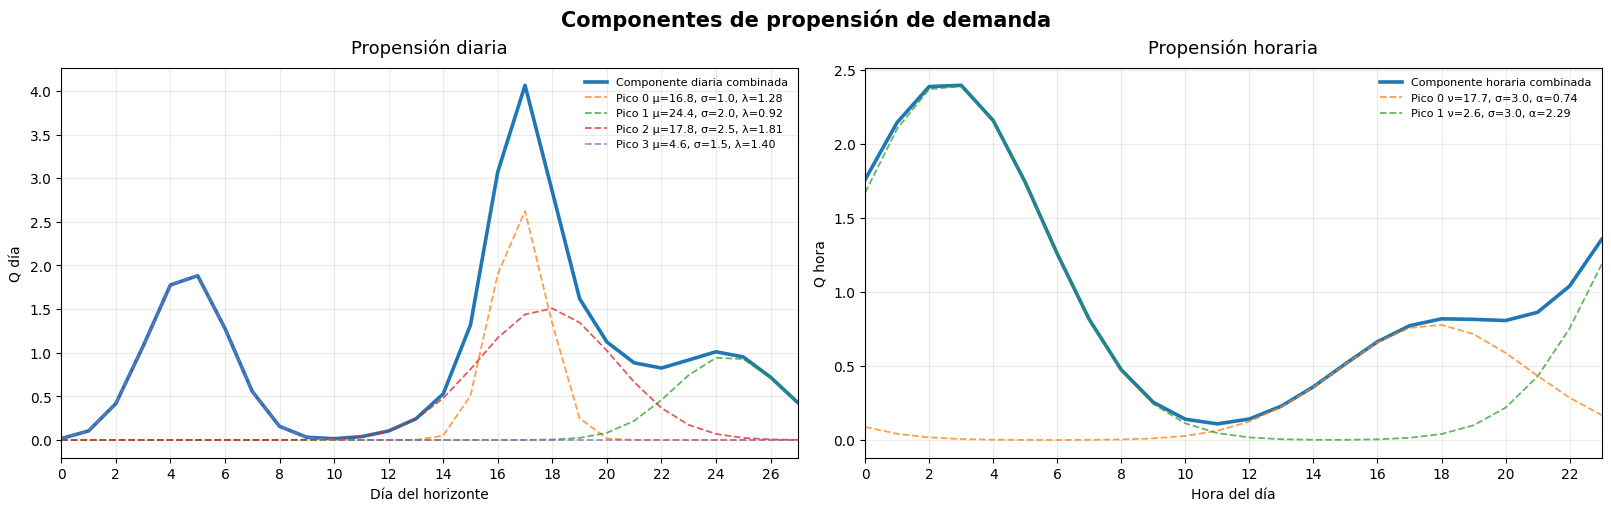

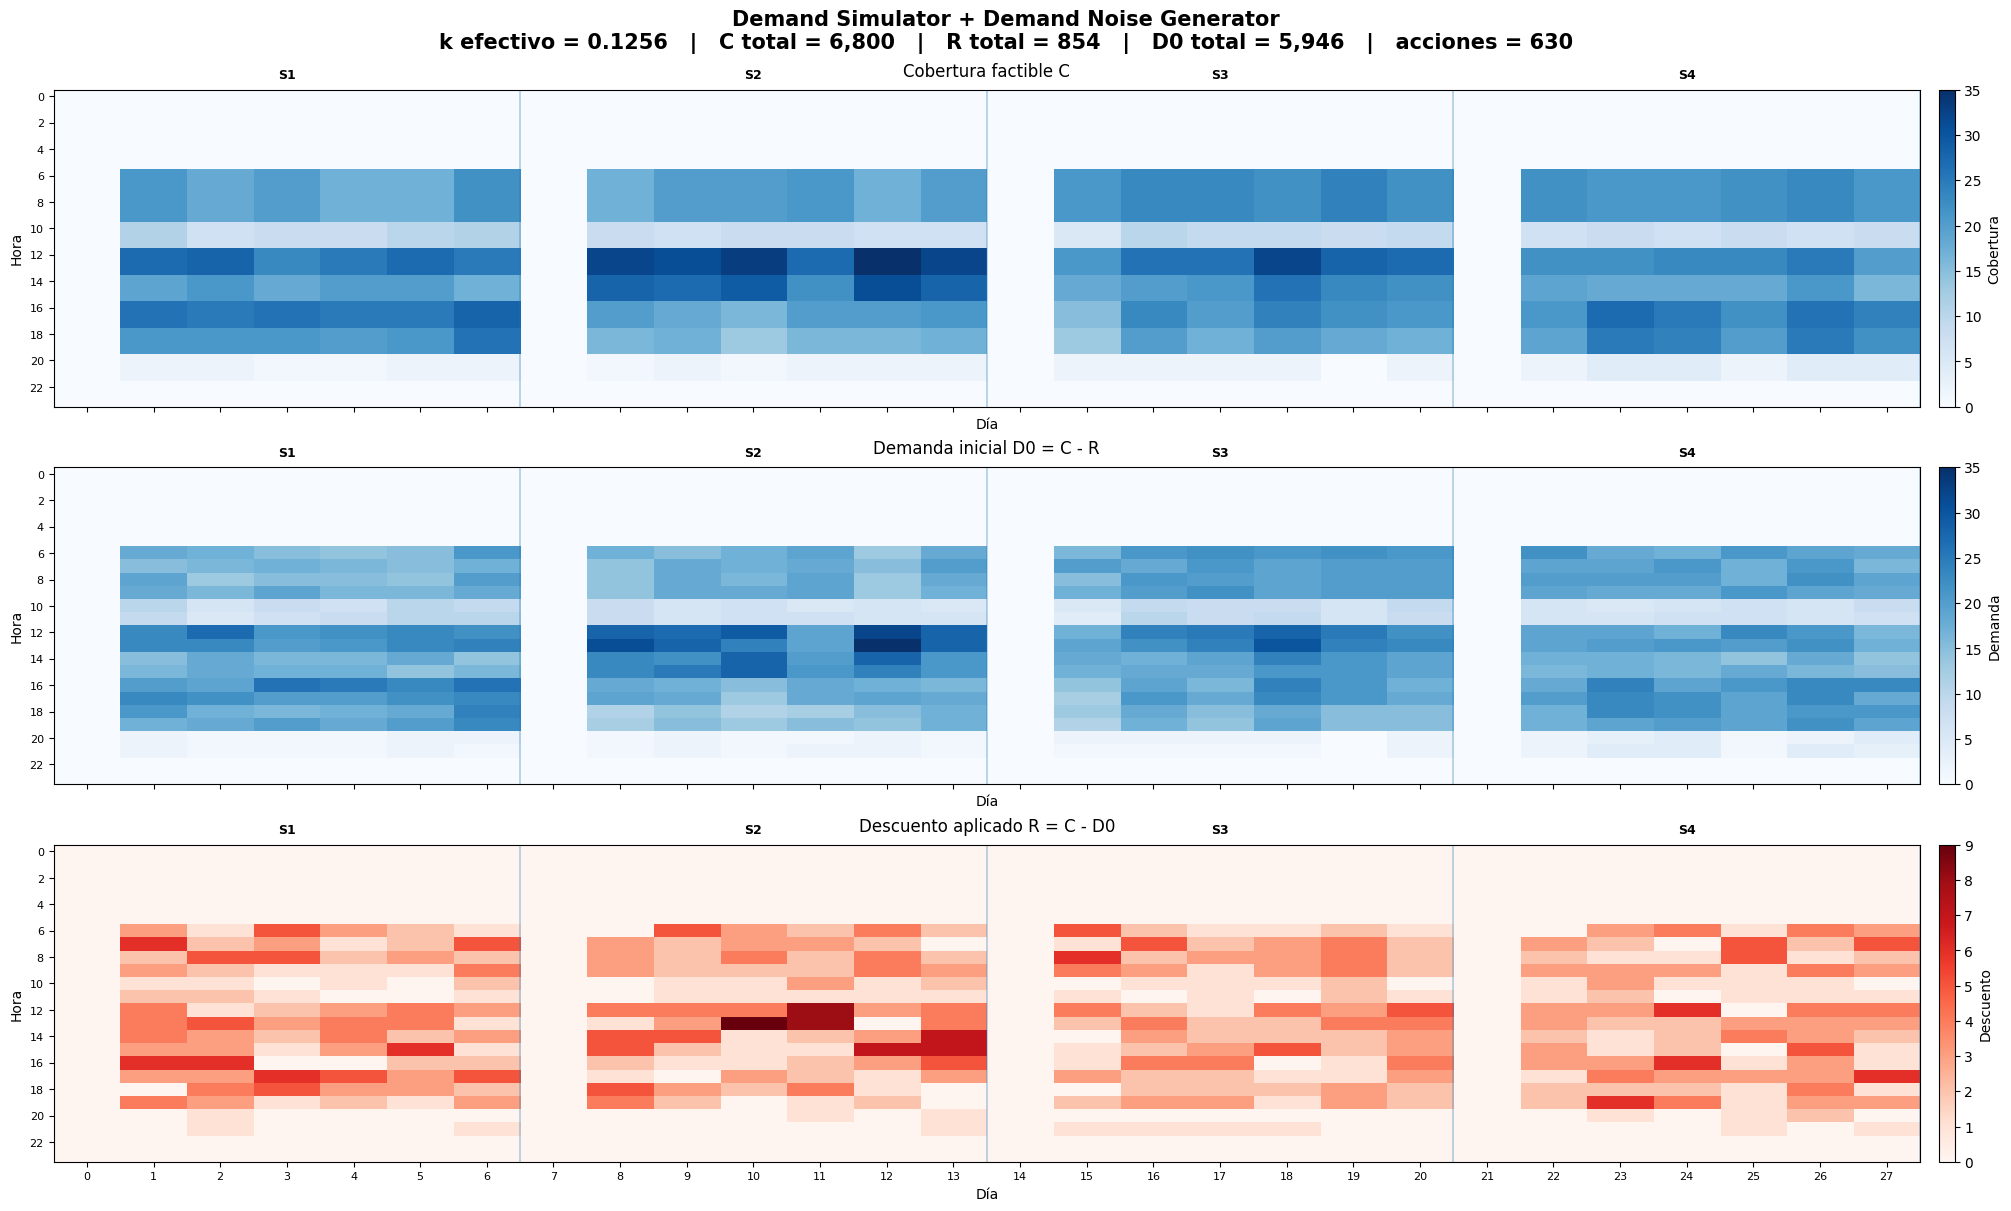

In [90]:
# Grafico el resultado (heatmap)
plot_demand_simulation_clean(
    coverage_matrix=coverage_matrix,
    noise_result=noise_result,
    trajectory=trajectory,
    show_values=False,
)